In [54]:
import numpy as np
import pandas as pd
import os
import OptimalBattery.plot as plot
import matplotlib.pyplot as plt
import seaborn as sns
import OptimalBattery.global_config as gcf

save_dir = gcf.save_dir

In [55]:
# load tsv with eval data
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'real_parcellation_cerebellum_2.tsv')
D = pd.read_csv(saved_file, sep='\t')

In [51]:
# defube metrics to plot
metrics = ['random','variance','inverse_trace_mc','log_det_mc']
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1

In [52]:
custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

C:\Users\barafat\AppData\Local\Temp\ipykernel_25000\3686812811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


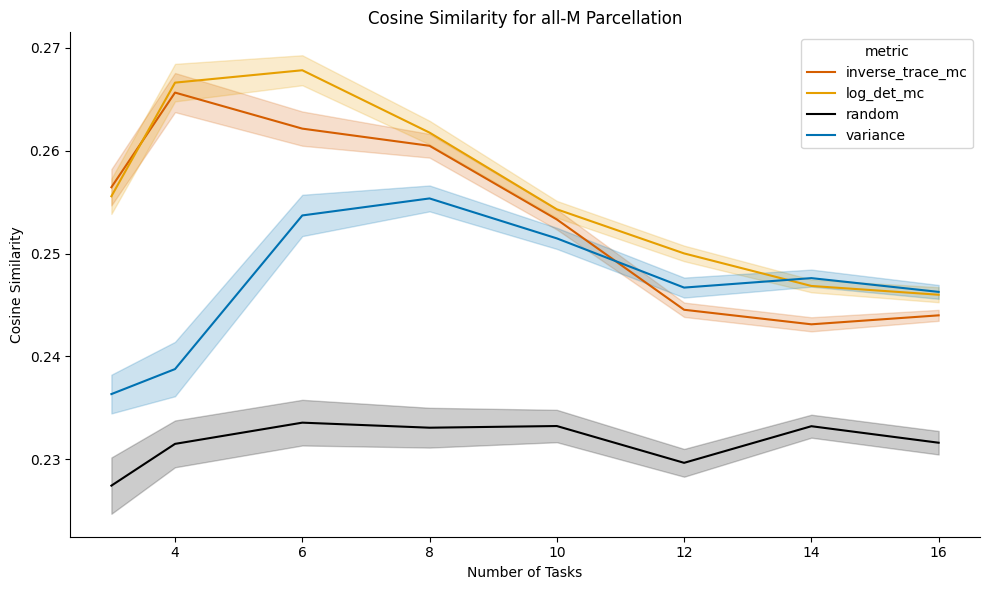

C:\Users\barafat\AppData\Local\Temp\ipykernel_25000\3686812811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


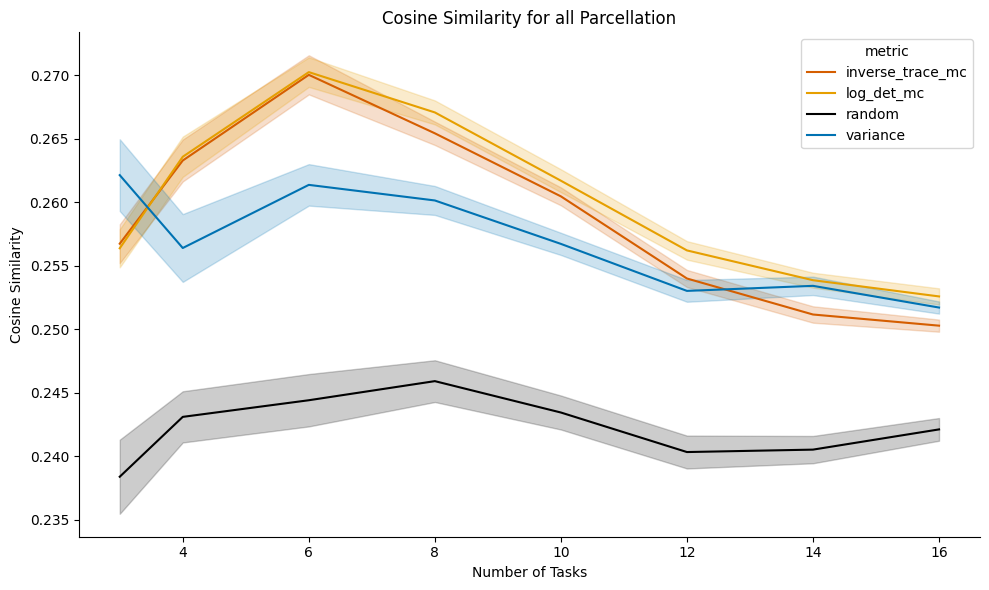

C:\Users\barafat\AppData\Local\Temp\ipykernel_25000\3686812811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


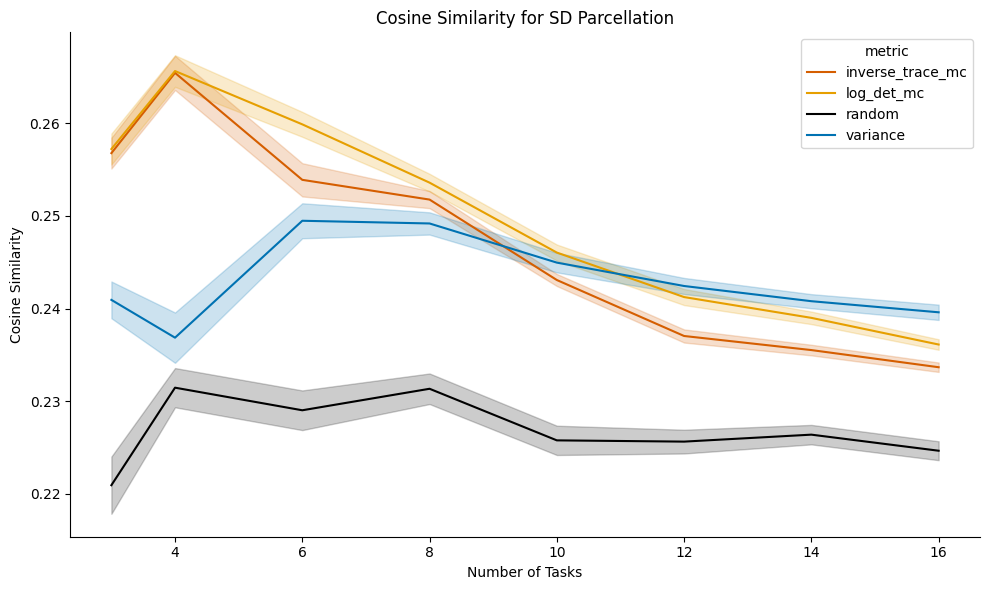

C:\Users\barafat\AppData\Local\Temp\ipykernel_25000\3686812811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


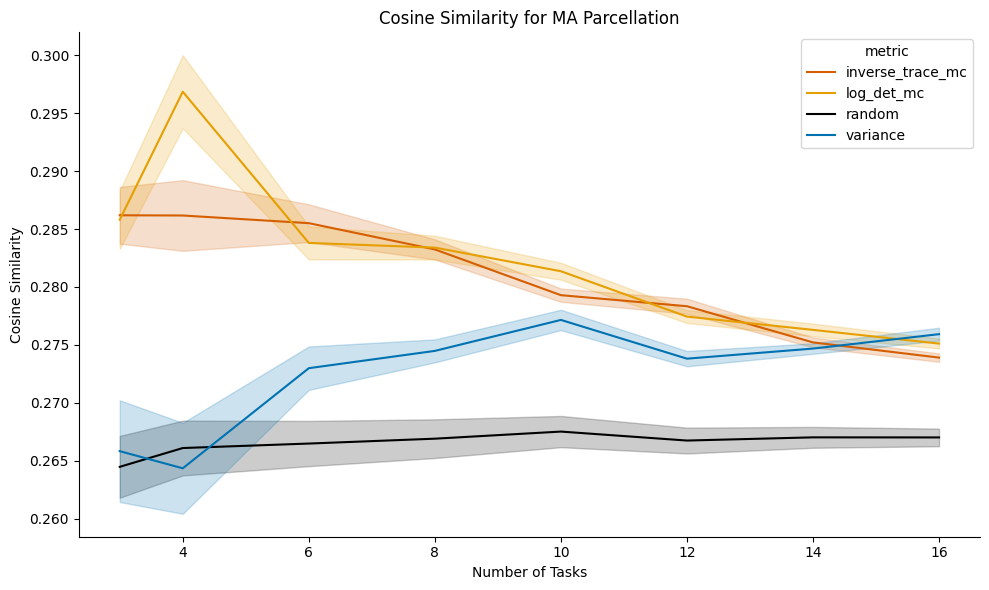

C:\Users\barafat\AppData\Local\Temp\ipykernel_25000\3686812811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


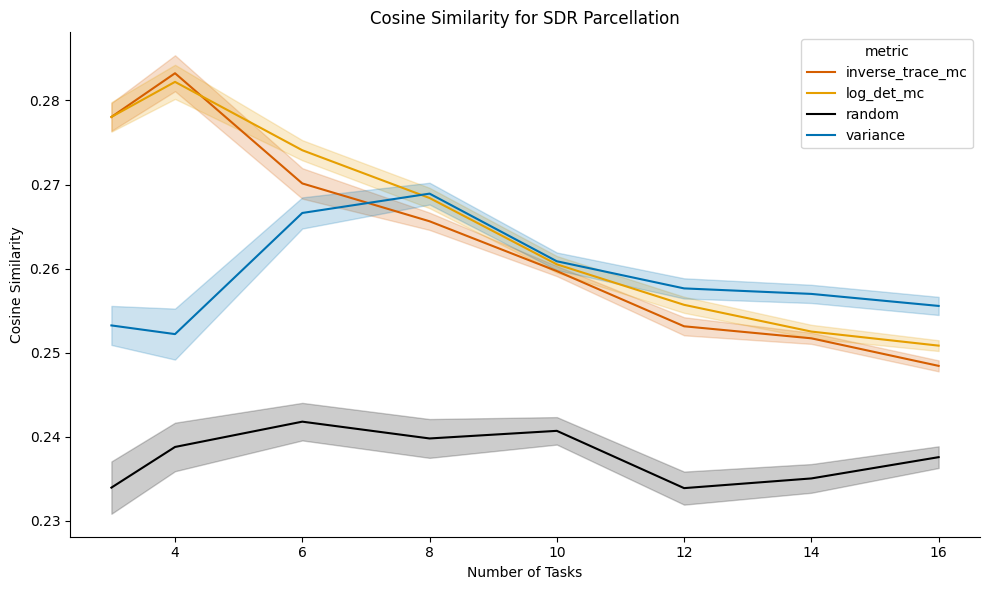

C:\Users\barafat\AppData\Local\Temp\ipykernel_25000\3686812811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


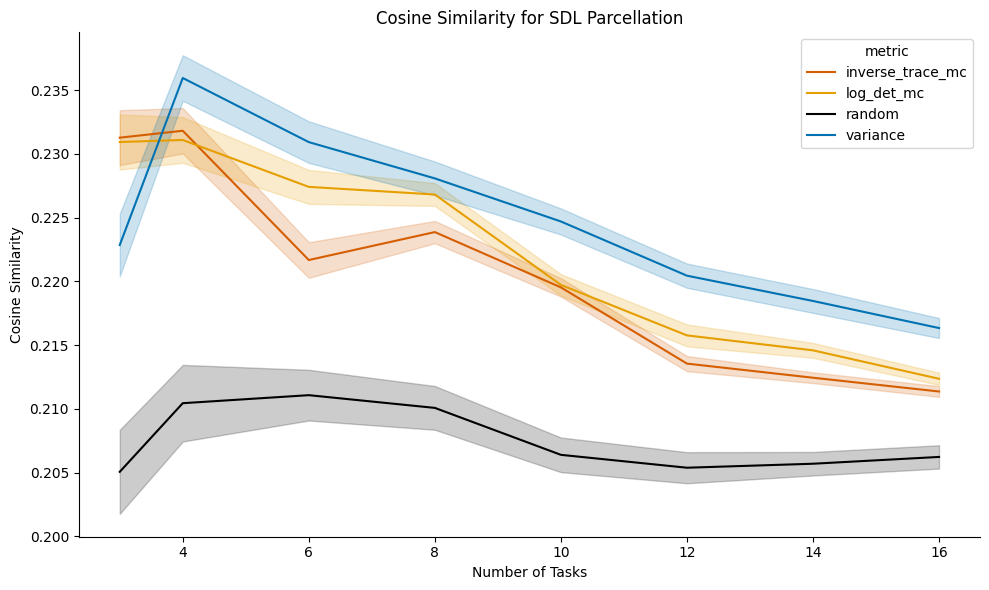

C:\Users\barafat\AppData\Local\Temp\ipykernel_25000\3686812811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


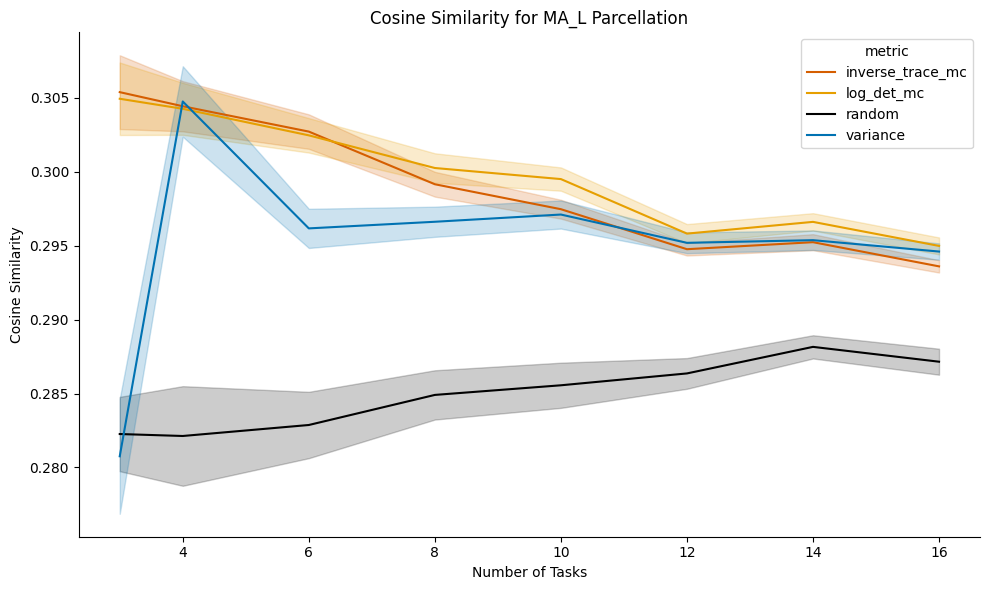

C:\Users\barafat\AppData\Local\Temp\ipykernel_25000\3686812811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


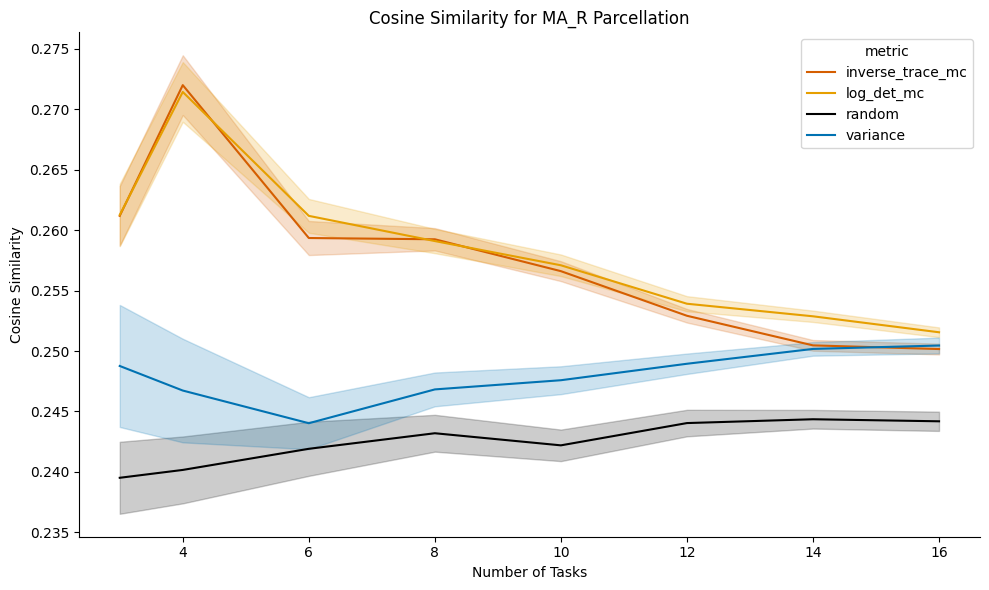

C:\Users\barafat\AppData\Local\Temp\ipykernel_25000\3686812811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


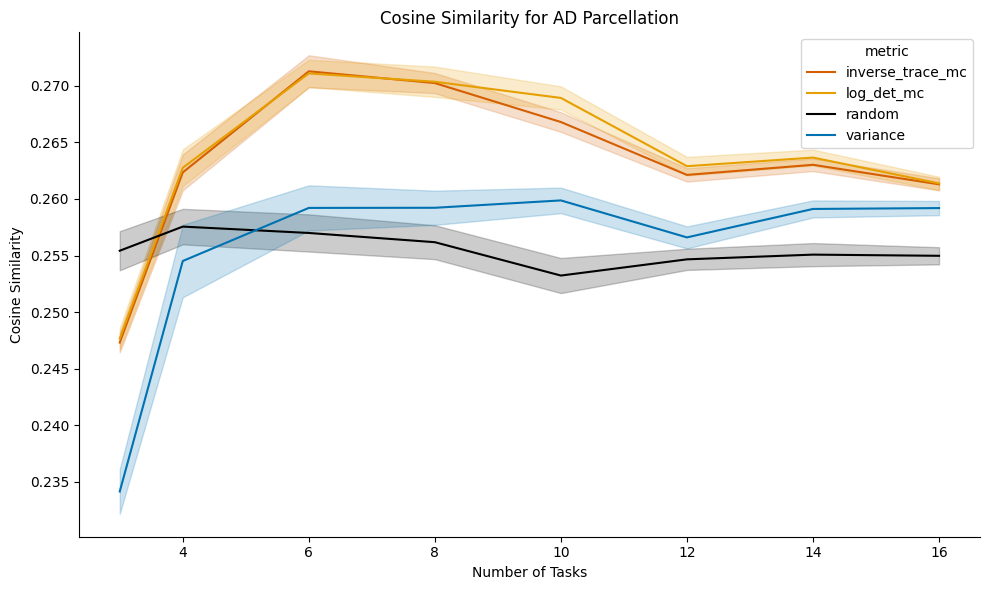

In [53]:
# check unique ROIs
rois = D['roi'].unique()
for roi in rois:
    df_roi = D[D['roi'] == roi]

    # Step 1: compute the group mean per n_task
    task_mean = df_roi.groupby("n_task")["avg_cos_sim_per_subject"].transform("mean")

    # Step 2: compute each subject’s mean within that n_task
    subject_mean = df_roi.groupby(["n_task", "sub"])["avg_cos_sim_per_subject"].transform("mean")

    # Step 3 & 4: remove subject effect, add group mean
    df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean


    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_roi,
        x="n_task",
        y="adjusted",
        hue="metric",
        errorbar='se',
        palette=custom_palette,
    )

    plt.xlabel("Number of Tasks")
    plt.ylabel("Cosine Similarity")
    plt.title(f"Cosine Similarity for {roi} Parcellation")
    plt.tight_layout()
    sns.despine()
    plt.savefig(f"{save_dir}/battery_criteria/real_cerebellar_{roi}.pdf", format="pdf", bbox_inches="tight")
    plt.show()